# Лабораторная работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды.

Выполнили студенты гр. 2384 Лукьянова Мария и Пчелинцева Кристина.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

**Генеральная совокупность** — совокупность всех возможных наблюдений, относительно которых предполагается делать выводы при постановке гипотезы.

**Выборка** — часть генеральной совокупности, которая была охвачена сбором данных.

**Статистический ряд** - последовательность элементов выборки, расположенных в порядке из получения (наблюдения)

**Ранжированный ряд** - последовательность элементов выборки, расположенных в порядке возрастания их значений.

**Ранг** - номер элемента ранжированного ряда.

**Вариационный ряд** - получается из ранжированного ряда в результате объединения одинаковых элементов.

**Варианта** - элемент вариационного ряда.

**Интервальный ряд** - вариационный ряд, разделенный на интервалы.

**Формула Стерджеса**: $k=1+3.322 \cdot lgN$

**Ширина интервала h**: $h =\frac{x_{max}-x_{min}}{k}$

**Абсолютные интервальные частоты** - cоответствующие вариантам $x_i$ числа $n_i$.

**Относительные интервальные частоты** - вычисляются как отношение абсолютной частоты на объем выборки.

**Полигон частот** - это ломаная, вершинами которой являются точки с координатами, соответствующими парам значений (среднее значение интервала; частота интервала)

**Гистограмма частот** - называется расположенная в прямоугольной системе
координат геометрическая фигура, состоящая из прямоугольников, основаниями
которых являются откладываемые по оси $Ох$ интервалы $[х_{i-1}; x_i)$
шириной $h$, а соответствующими им высотами могут быть откладываемые по
оси $Оy$ (относительные) частоты.

**Эмпирическая функция распределения** - функция $F^*(x)$, определяющая для каждого значения $x$ относительную частоту события $X<x$

График $F^*(x)$ представляет собой лестнечный график, длина каждой стуеньки которого равна длине соответствующего интервала, а высота - отношению накопленной частоты до середины этого интервала к объему выборки:

$F^*(\tilde{x}_i)=\frac{m_i^{нак}}{N}$, где

$\sum_{j=1}^{i-1}m_j$, $i=1,2,...,k+1$ - **накоплленные частоты**

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных.

Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

### 1. Обоснование выбора ПО

Для выполнения практической работы выбран язык программирования Python. Выбор обусловлен возможностью автоматизированной обработки данных (pandas), построения графиков (matplotlib), формирования статистических рядов и воспроизводимости результатов.

### 2. Генеральная совокупность

Генеральная совокупность представлена данными о продаже автомобилей Audi A1, опубликованными на платформе Kaggle: https://www.kaggle.com/datasets/jacklacey/audi-a1-listings/data .

Данные включают количественные характеристики автомобилей. В рамках работы рассматриваются две непрерывные количественные переменные: мощность двигателя и цена за год. Все переменные в выборке имеют вещественное значение.

### 3. Формирование выборки

Выборка объёма n = 111 сформирована методом простой случайной бесповторной выборки с использованием генератора случайных чисел (random_state=42) в среде Python.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
# df = pd.read_csv("Audi_A1_listings.csv", sep=";", encoding="latin1")
# df = df[["PS", "PPY"]]
# df = df.dropna()
# sample = df.sample(n=111, random_state=42)
# sample.to_csv("team33_pr1.csv", index=False)

In [3]:
from google.colab import files

#используем согласованную выборку
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("team33_pr1.csv")
df

Saving team33_pr1.csv to team33_pr1.csv


,PS,PPY
0,123.274162,2694.000000
1,93.688363,3448.333333
2,114.398422,2213.571429
3,147.928994,3375.000000
4,123.274162,2830.833333
...,...,...
106,148.000000,3419.750000
107,93.688363,3525.000000
108,114.398422,2500.000000
109,123.274162,2358.000000


### 4. Обработка



#### 4.1 Ранжированный ряд

In [4]:
# Для PS
PS_ranked = df['PS'].sort_values().reset_index(drop=True)
print("Ранжированный ряд PS:")
print(PS_ranked.head())

# Для PPY
PPY_ranked = df['PPY'].sort_values().reset_index(drop=True)
print("\nРанжированный ряд PPY:")
print(PPY_ranked.head())

Ранжированный ряд PS:
0    84.812623
1    93.000000
2    93.000000
3    93.000000
4    93.688363
Name: PS, dtype: float64

Ранжированный ряд PPY:
0    1749.166667
1    1822.250000
2    1830.000000
3    2000.000000
4    2049.000000
Name: PPY, dtype: float64


#### 4.2 Вариационный ряд

In [5]:
# Вариационный ряд PS
PS_variation = df['PS'].value_counts().sort_index()
print("Вариационный ряд PS:")
print(PS_variation.head())

# Вариационный ряд PPY
PPY_variation = df['PPY'].value_counts().sort_index()
print("\nВариационный ряд PPY:")
print(PPY_variation.head())

Вариационный ряд PS:
PS
84.812623      1
93.000000      3
93.688363     15
94.000000      2
103.550296     7
Name: count, dtype: int64

Вариационный ряд PPY:
PPY
1749.166667    1
1822.250000    1
1830.000000    1
2000.000000    1
2049.000000    1
Name: count, dtype: int64


#### 4.3 Интервальный ряд

4.3.1 Мощность двигателя

In [6]:
import math
import pandas as pd

N = len(df)
k = math.ceil(1 + 3.322 * math.log10(N))
min_ps = df['PS'].min()
max_ps = df['PS'].max()
h = (max_ps - min_ps)/k

PS_intervals = pd.cut(df['PS'], bins=k)

PS_freq = df.groupby(PS_intervals, observed=False)['PS'].count()
PS_freq_rel = PS_freq / N

PS_freq_cum = PS_freq.cumsum()
PS_freq_rel_cum = PS_freq_rel.cumsum()

PS_mid = [(interval.left + interval.right)/2 for interval in PS_freq.index]

PS_table = pd.DataFrame({
    'Интервал PS': PS_freq.index,
    'Середина ~x_i': PS_mid,
    'Абсолютная частота m_i': PS_freq.values,
    'Относительная частота ~m_i': PS_freq_rel.values,
    'Накопленная абсолютная m_нак_i': PS_freq_cum.values,
    'Накопленная относительная ~m_нак_i': PS_freq_rel_cum.values
})

sum_row = pd.DataFrame({
    'Интервал PS': ['Σ'],
    'Середина ~x_i': ['-'],
    'Абсолютная частота m_i': [PS_freq.sum()],
    'Относительная частота ~m_i': [PS_freq_rel.sum()],
    'Накопленная абсолютная m_нак_i': ['-'],
    'Накопленная относительная ~m_нак_i': ['-']
})

PS_table = pd.concat([PS_table, sum_row], ignore_index=True)

# Вывод
print(f'Объём выборки: {N}\nКоличество интервалов: {k}\nМин: {min_ps}')
print(f'Макс: {max_ps}\nШирина интервала: {h:.2f}\n')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.colheader_justify', 'center')
print(PS_table)

Объём выборки: 111
Количество интервалов: 8
Мин: 84.81262327416174
Макс: 148.0
Ширина интервала: 7.90

      Интервал PS     Середина ~x_i  Абсолютная частота m_i  Относительная частота ~m_i Накопленная абсолютная m_нак_i Накопленная относительная ~m_нак_i
0    (84.749, 92.711]       88.73                1                    0.009009                          1                           0.009009             
1   (92.711, 100.609]       96.66               20                    0.180180                         21                           0.189189             
2  (100.609, 108.508]    104.5585               11                    0.099099                         32                           0.288288             
3  (108.508, 116.406]     112.457               29                    0.261261                         61                            0.54955             
4  (116.406, 124.305]    120.3555               31                    0.279279                         92                      

4.3.1 Цена за год

In [7]:
min_ppy = df['PPY'].min()
max_ppy = df['PPY'].max()
h_ppy = (max_ppy - min_ppy)/k

PPY_intervals = pd.cut(df['PPY'], bins=k)
PPY_freq = df.groupby(PPY_intervals, observed=False)['PPY'].count()

interval_mid_ppy = [(interval.left + interval.right)/2 for interval in PPY_freq.index]

cum_abs_ppy = PPY_freq.cumsum()
cum_rel_ppy = (PPY_freq/N).cumsum()

PPY_table = pd.DataFrame({
    'Интервал PPY': PPY_freq.index,
    'Середина ~x_i': interval_mid_ppy,
    'Абсолютная частота m_i': PPY_freq.values,
    'Относительная частота ~m_i': PPY_freq.values/N,
    'Накопленная абсолютная m_нак_i': cum_abs_ppy.values,
    'Накопленная относительная ~m_нак_i': cum_rel_ppy.values
})

PPY_table.loc[len(PPY_table)] = ['Σ', '-', cum_abs_ppy.iloc[-1], cum_rel_ppy.iloc[-1], '-', '-']

# Вывод
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(f'Объём выборки: {N}\nКоличество интервалов: {k}\nМин: {min_ppy}')
print(f'Макс: {max_ppy}\nШирина интервала: {h_ppy:.2f}\n')
print(PPY_table)


Объём выборки: 111
Количество интервалов: 8
Мин: 1749.1666666666667
Макс: 5637.5
Ширина интервала: 486.04

       Интервал PPY     Середина ~x_i  Абсолютная частота m_i  Относительная частота ~m_i Накопленная абсолютная m_нак_i Накопленная относительная ~m_нак_i
0  (1745.278, 2235.208]     1990.243              13                    0.117117                         13                           0.117117             
1   (2235.208, 2721.25]     2478.229              35                    0.315315                         48                           0.432432             
2   (2721.25, 3207.292]     2964.271              31                    0.279279                         79                           0.711712             
3  (3207.292, 3693.333]    3450.3125               9                    0.081081                         88                           0.792793             
4  (3693.333, 4179.375]     3936.354              13                    0.117117                        101      

##### 4.3.3 Анализ

Были проанализированы две выборки: мощность двигателя (PS) и цена за год (PPY). Для каждой выборки построены ранжированный, вариационный и интервальный ряды, а также рассчитаны средние значения в каждом интервале.

Мощность двигателя (PS): значения сосредоточены в диапазоне 100–125 л.с., крайние значения встречаются редко (меньше 93 и больше 140 л.с.). Наибольшая абсолютная частота наблюдается в интервалах [108.51, 116.41) и [116.41, 124.31), что соответствует средней части диапазона. Накопленные частоты показывают, что около 83% автомобилей имеют мощность до 124 л.с. Интервал (124.305, 132.203] не содержит наблюдений, что свидетельствует о разрыве в
распределении. Относительные частоты подтверждают, что большинство автомобилей сосредоточено в среднем диапазоне, а крайние значения встречаются значительно реже. Распределение имеет умеренную асимметрию вправо: встречаются единичные значения на больших мощностях.

Цена за год (PPY): значения сосредоточены в диапазоне 2235–3207 фунтов стерлингов, крайние цены встречаются реже. Наибольшая абсолютная частота у интервалов [2235, 2721) и [2721, 3207) — почти 71% автомобилей стоят до 3207 фунтов стерлингов. Остальные интервалы содержат значительно меньшее количество автомобилей, что отражает скошенность распределения вправо. Относительные и накопленные частоты подтверждают концентрацию значений в среднем диапазоне и редкое появление крайних значений.

### 5. Визуализация
#### 5.1 Абсолютные частоты
##### 5.1.1 Мощность двигателя (PS)

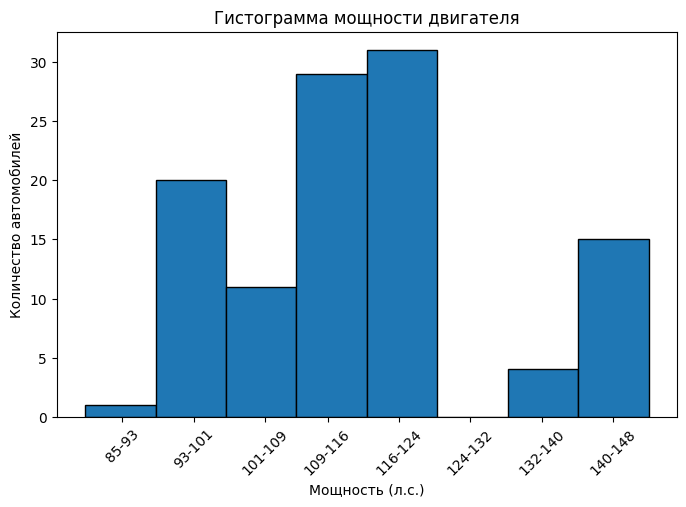

In [8]:
interval_mid_rounded = [round(x, 0) for x in PS_mid]
intervals = PS_freq.index
tick_labels = [f"{int(round(interval.left,0))}-{int(round(interval.right,0))}" for interval in intervals]

plt.figure(figsize=(8,5))
plt.hist(df['PS'], bins=k, edgecolor='black')
plt.title("Гистограмма мощности двигателя")
plt.xlabel("Мощность (л.с.)")
plt.ylabel("Количество автомобилей")
plt.xticks(interval_mid_rounded, tick_labels, rotation=45)
plt.show()

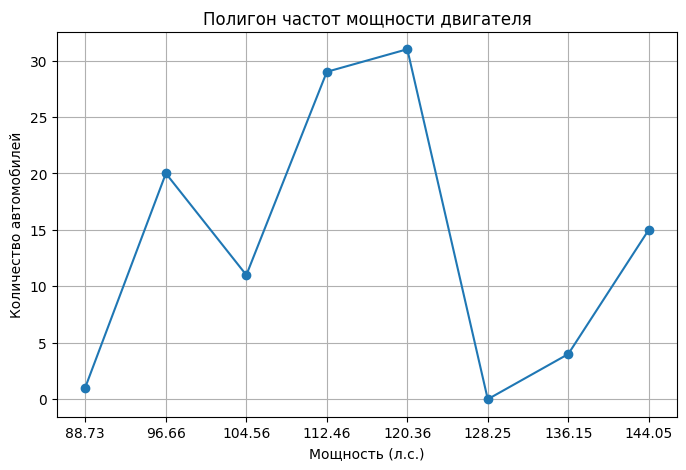

In [9]:
plt.figure(figsize=(8,5))
interval_mid = [(interval.left + interval.right)/2 for interval in PS_freq.index]
plt.plot(interval_mid, PS_freq.values, marker='o')
plt.title("Полигон частот мощности двигателя")
plt.xlabel("Мощность (л.с.)")
plt.ylabel("Количество автомобилей")
plt.xticks(interval_mid)
plt.grid(True)
plt.show()

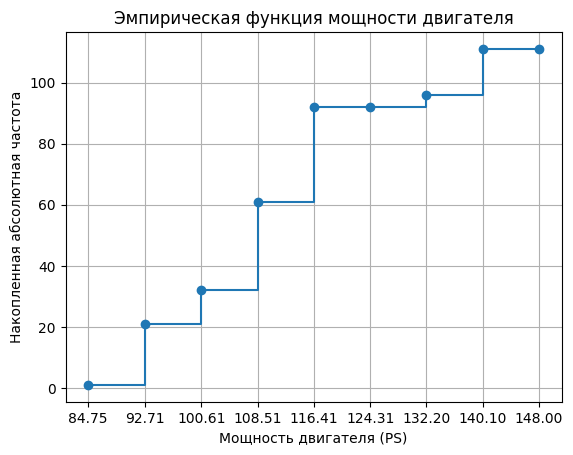

In [11]:
F_x = PS_table['Накопленная абсолютная m_нак_i'][:-1].values
x_vals = [interval.left for interval in PS_freq.index]
x_vals.append(PS_freq.index[-1].right)

F_x = list(F_x)
F_x.append(N)

plt.step(x_vals, F_x, where='post', marker='o')
plt.xlabel("Мощность двигателя (PS)")
plt.ylabel("Накопленная абсолютная частота")
plt.title("Эмпирическая функция мощности двигателя")
plt.xticks(x_vals)
plt.grid(True)
plt.show()

На гистограмме и полигоне видно, что большинство автомобилей сосредоточено в диапазоне 109–124 л.с., крайние значения встречаются редко. Эмпирическая функция нарастает ступенчато, с резким ростом в среднем диапазоне, и в конце наблюдается небольшой подъём, отражающий редкие высокие значения мощности.

##### 5.1.2 Цена за год

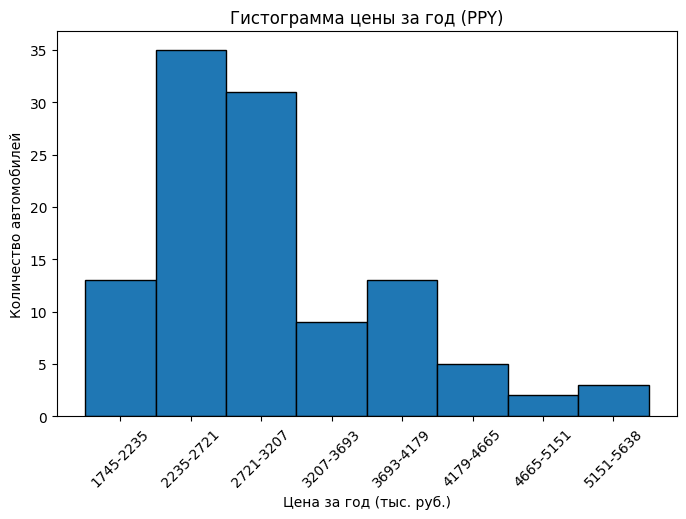

In [12]:
interval_mid_rounded = [round(x, 0) for x in interval_mid_ppy]
intervals_ppy = PPY_freq.index
tick_labels_ppy = [f"{int(round(intervals_ppy.left,0))}-{int(round(intervals_ppy.right,0))}" for intervals_ppy in intervals_ppy]

plt.figure(figsize=(8,5))
plt.hist(df['PPY'], bins=k, edgecolor='black')
plt.title("Гистограмма цены за год (PPY)")
plt.xlabel("Цена за год (тыс. руб.)")
plt.ylabel("Количество автомобилей")
plt.xticks(interval_mid_rounded, tick_labels_ppy, rotation=45)
plt.show()


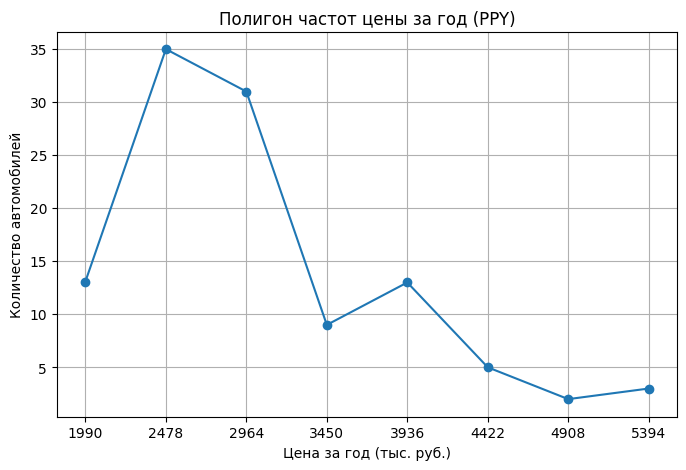

In [14]:
plt.figure(figsize=(8,5))
plt.plot(interval_mid_ppy, PPY_freq.values, marker='o')
plt.title("Полигон частот цены за год (PPY)")
plt.xlabel("Цена за год (тыс. руб.)")
plt.ylabel("Количество автомобилей")
plt.xticks(interval_mid_ppy)
plt.grid(True)
plt.show()

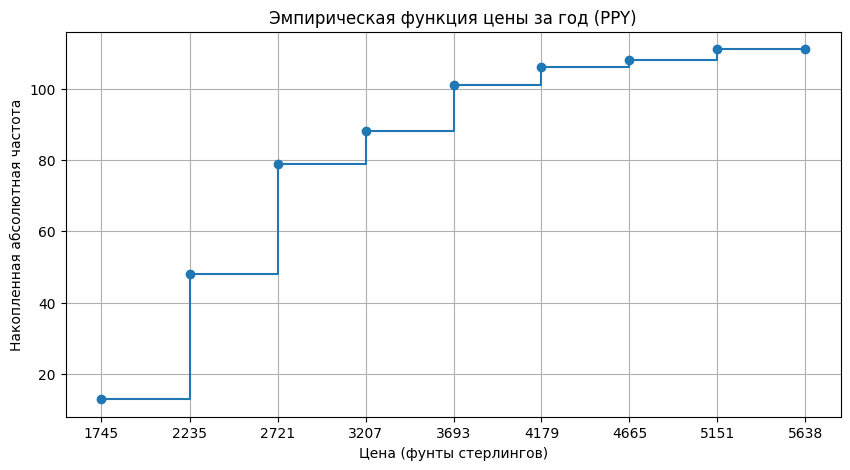

In [15]:
F_x = PPY_table['Накопленная абсолютная m_нак_i'][:-1].values
x_vals = [interval.left for interval in PPY_freq.index]
x_vals.append(PPY_freq.index[-1].right)

F_x = list(F_x)
F_x.append(N)

plt.figure(figsize=(10,5))
plt.step(x_vals, F_x, where='post', marker='o')
plt.title("Эмпирическая функция цены за год (PPY)")
plt.xlabel("Цена (фунты стерлингов)")
plt.ylabel("Накопленная абсолютная частота")
plt.xticks(x_vals)
plt.grid(True)
plt.show()


На гистограмме и полигоне большая часть автомобилей сосредоточена в диапазоне 2235–3207 фунтов стерлингов, пик приходится на интервалы 2235–2721 и 2721–3207. Более дорогие автомобили встречаются значительно реже, самые дешёвые — немногочисленны. Эмпирическая функция показывает ступенчатое нарастание, с резким ростом в среднем диапазоне цен

#### 5.2 Относительные частоты
##### 5.2.1 Мощность двигателя

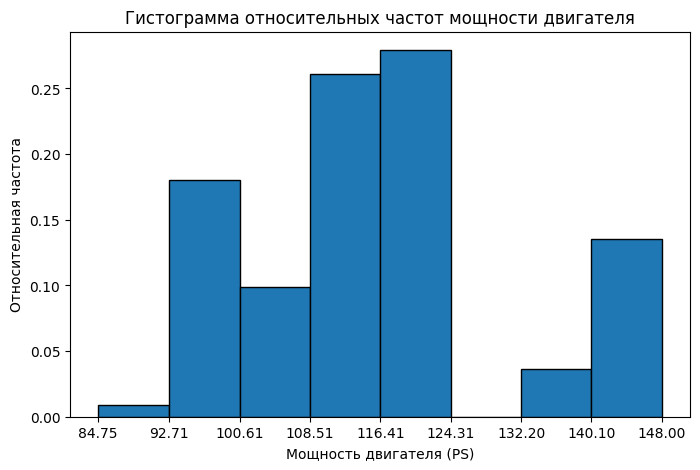

In [16]:
plt.figure(figsize=(8,5))
plt.bar([interval.left for interval in PS_freq.index], PS_freq_rel.values,
        width=[interval.right-interval.left for interval in PS_freq.index],
        edgecolor='black', align='edge')
plt.xlabel("Мощность двигателя (PS)")
plt.ylabel("Относительная частота")
plt.title("Гистограмма относительных частот мощности двигателя")
plt.xticks([interval.left for interval in PS_freq.index] + [PS_freq.index[-1].right])
plt.show()

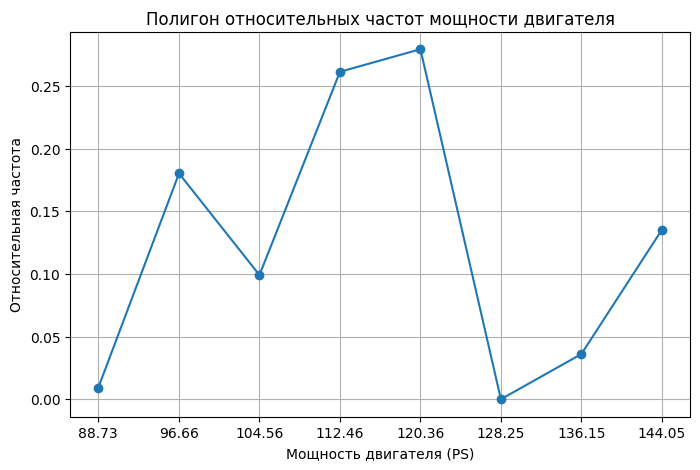

In [17]:
PS_mid_graph = PS_mid[:k]
PS_rel_graph = PS_freq_rel.values

plt.figure(figsize=(8,5))
plt.plot(PS_mid_graph, PS_rel_graph, marker='o', linestyle='-')
plt.xlabel("Мощность двигателя (PS)")
plt.ylabel("Относительная частота")
plt.title("Полигон относительных частот мощности двигателя")
plt.xticks(PS_mid_graph)
plt.grid(True)
plt.show()

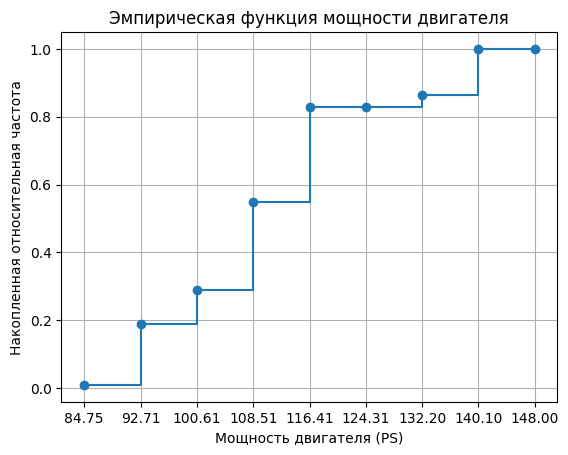

In [18]:
F_x = PS_table['Накопленная относительная ~m_нак_i'][:-1].values
x_vals = [interval.left for interval in PS_freq.index]
x_vals.append(PS_freq.index[-1].right)

F_x = list(F_x)
F_x.append(1)

plt.step(x_vals, F_x, where='post', marker='o')
plt.xlabel("Мощность двигателя (PS)")
plt.ylabel("Накопленная относительная частота")
plt.title("Эмпирическая функция мощности двигателя")
plt.xticks(x_vals)
plt.grid(True)
plt.show()

##### 5.2.2 Цена за год

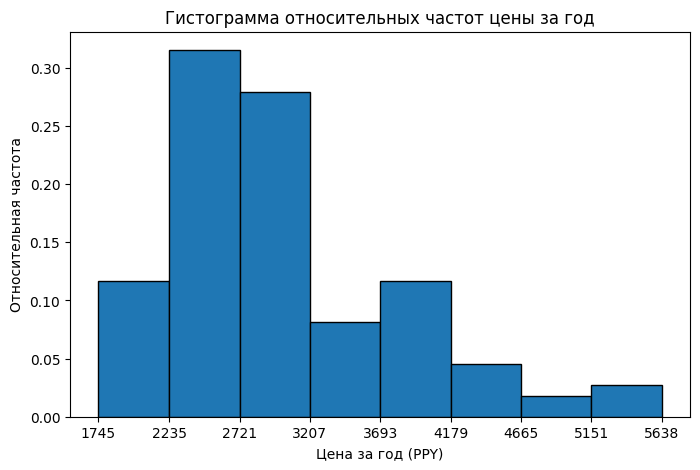

In [19]:
PPY_freq_rel = PPY_freq/N

plt.figure(figsize=(8,5))
plt.bar([interval.left for interval in PPY_freq.index], PPY_freq_rel.values,
        width=[interval.right-interval.left for interval in PPY_freq.index],
        edgecolor='black', align='edge')
plt.xlabel("Цена за год (PPY)")
plt.ylabel("Относительная частота")
plt.title("Гистограмма относительных частот цены за год")
plt.xticks([interval.left for interval in PPY_freq.index] + [PPY_freq.index[-1].right])
plt.show()

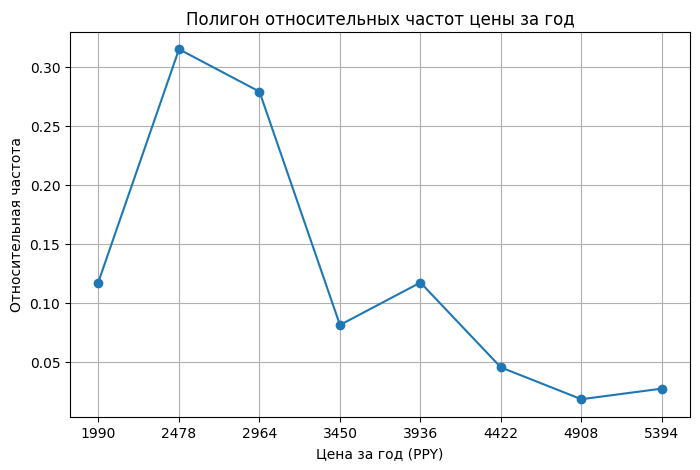

In [20]:
PPY_mid_graph = interval_mid_ppy[:k]
PPY_rel_graph = PPY_freq_rel.values

plt.figure(figsize=(8,5))
plt.plot(PPY_mid_graph, PPY_rel_graph, marker='o', linestyle='-')
plt.xlabel("Цена за год (PPY)")
plt.ylabel("Относительная частота")
plt.title("Полигон относительных частот цены за год")
plt.xticks(PPY_mid_graph)
plt.grid(True)
plt.show()

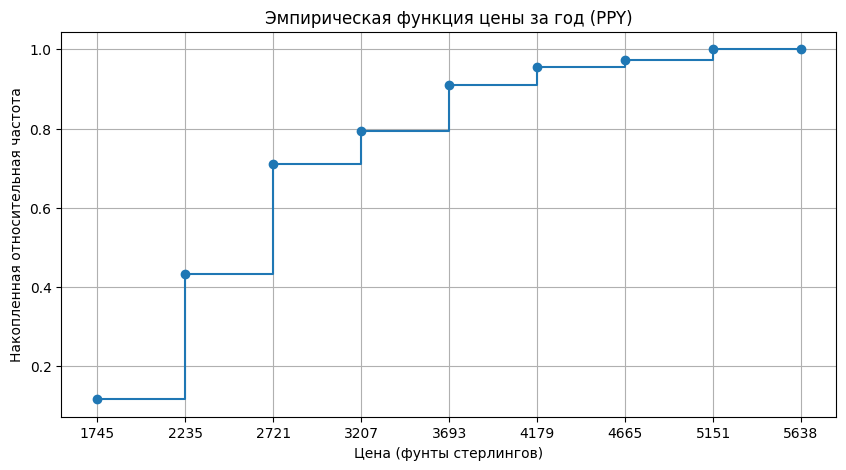

In [21]:
F_x = PPY_table['Накопленная относительная ~m_нак_i'][:-1].values
x_vals = [interval.left for interval in PPY_freq.index]
x_vals.append(PPY_freq.index[-1].right)

F_x = list(F_x)
F_x.append(1)

plt.figure(figsize=(10,5))
plt.step(x_vals, F_x, where='post', marker='o')
plt.title("Эмпирическая функция цены за год (PPY)")
plt.xlabel("Цена (фунты стерлингов)")
plt.ylabel("Накопленная относительная частота")
plt.xticks(x_vals)
plt.grid(True)
plt.show()


Построенные графики относительных частот отражают структуру распределения данных в нормированной форме. Поскольку относительная частота представляет собой долю наблюдений в каждом интервале, форма графиков полностью повторяет графики абсолютных частот и отличается только масштабом по оси Y.

Дополнительной информации по сравнению с абсолютными частотами данные графики не дают, так как построены на основе тех же выборок. Однако использование относительных частот целесообразно при сравнении различных выборок между собой, поскольку нормализация по объёму выборки позволяет корректно сопоставлять распределения независимо от числа наблюдений.

Таким образом, графики абсолютных и относительных частот имеют одинаковую форму и отражают одну и ту же структуру распределения, различаясь лишь единицами измерения по вертикальной оси.

## Выводы

В ходе выполнения лабораторной работы была сформирована выборка из исходного датасета, содержащего информацию о мощности двигателя автомобилей (PS) и цене за год (PPY). Для каждого признака был проведён последовательный статистический анализ.

Полученные данные были преобразованы в ранжированные ряды, что позволило упорядочить значения признаков по возрастанию и определить их минимальные и максимальные значения. На основе ранжированных рядов были построены вариационные ряды, в которых каждому значению сопоставлена его частота встречаемости. Это дало представление о характере распределения и наиболее распространённых значениях показателей.

Далее были сформированы интервальные ряды распределения. Количество интервалов было определено по формуле Стерджеса, а ширина интервала рассчитана исходя из размаха выборки. Для каждого интервала были вычислены абсолютные, относительные и накопленные частоты.

На основе интервальных рядов были построены гистограммы, полигоны и эмпирические функции распределения как для абсолютных, так и для относительных частот. Гистограммы и полигоны позволили наглядно оценить форму распределения данных и выявить интервалы с наибольшей концентрацией наблюдений. Эмпирическая функция распределения показала накопление наблюдений и позволила определить долю (или количество) объектов, не превышающих заданного значения признака.

Сравнение графиков абсолютных и относительных частот показало, что они имеют одинаковую форму и отражают одну и ту же структуру распределения данных, различаясь лишь масштабом по оси ординат. Использование относительных частот особенно целесообразно при сравнении различных выборок, поскольку позволяет учитывать различия в их объёмах.

Таким образом, в ходе работы были закреплены навыки построения и анализа статистических рядов распределения, а также графической интерпретации полученных результатов для количественных признаков.